# Pima Indian Diabetes

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

### Setting up some plot parameters


In [ ]:
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

### Load the dataset


In [ ]:
file_path = '/content/drive/MyDrive/MLOpsAssignment/Assignment-data-diabetes.csv'
df = pd.read_csv(file_path)

# Display the first few rows and the information about the dataframe
display(df.head())
display(df.info())
print(df.describe())

# Making a copy for raw comparison
df_raw = df.copy()
print(f'\nDataset shape: {df.shape}')

print("\n")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

## 2. Preprocessing - Identifying issues

In [ ]:
# Checking for explicit missing
print('Missing values:')
print(df.isnull().sum())  # Should be zero

# Now, implicit missing: zeros in certain columns
# Columns where zero is problem: Glucose, BloodPressure, SkinThickness, Insulin, BMI
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('\nZeros in each column before fixing:')
total_zeros = 0
for col in cols_with_zeros:
    zero_count = (df[col] == 0).sum()
    total_zeros += zero_count
    print(f'{col}: {zero_count} zeros')

print(f'\nTotal problematic zeros found: {total_zeros}')

# Let me see the actual distribution first
print('\nChecking distributions with zeros:')
print(df[cols_with_zeros].describe())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zeros in each column before fixing:
Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros

Total problematic zeros found: 652

Checking distributions with zeros:
          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  768.000000     768.000000     768.000000  768.000000  768.000000
mean   120.894531      69.105469      20.536458   79.799479   31.992578
std     31.972618      19.355807      15.952218  115.244002    7.884160
min      0.000000       0.000000       0.000000    0.000000    0.000000
25%     99.000000      62.000000       0.000000    0.000000   27.300000
50%    117.000000      72.000000      23.000000   30.500000  

## 3. Fixing missing values

In [ ]:
# Replacing zeros with median - I think median is safer than mean for skewed data
for col in cols_with_zeros:
    # Get median excluding zeros
    non_zero_values = df[df[col] != 0][col]
    median_val = non_zero_values.median()
    zeros_before = (df[col] == 0).sum()
    df[col] = df[col].replace(0, median_val)
    print(f'Replaced {zeros_before} zeros in {col} with median: {median_val:.2f}')

# Checking for negatives or outliers
print('\nAny negatives after cleaning?', (df < 0).sum().sum())  # Should be none

# Double checking for duplicates
duplicates = df.duplicated().sum()
print(f'Duplicates found: {duplicates}')
if duplicates > 0:
    df = df.drop_duplicates()
    print('Duplicates removed')

# Hmm, data looks cleaner now
print('\nAfter cleaning summary:')
print(df.describe())


Replaced 5 zeros in Glucose with median: 117.00
Replaced 35 zeros in BloodPressure with median: 72.00
Replaced 227 zeros in SkinThickness with median: 29.00
Replaced 374 zeros in Insulin with median: 125.00
Replaced 11 zeros in BMI with median: 32.30

Any negatives after cleaning? 0
Duplicates found: 0

After cleaning summary:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  8

## 4. Normalisation/Standardisation

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Also prepare raw data for comparison
X_raw = df_raw.drop('Outcome', axis=1)
y_raw = df_raw['Outcome']
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# Standardizing - using StandardScaler for logistic reg
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Original train shape:', X_train.shape)
print('Scaled train shape:', X_train_scaled.shape)
print('Train feature means after scaling (should be ~0):', np.round(np.mean(X_train_scaled, axis=0), 3))
print('Train feature stds after scaling (should be ~1):', np.round(np.std(X_train_scaled, axis=0), 3))

Original train shape: (614, 8)
Scaled train shape: (614, 8)
Train feature means after scaling (should be ~0): [ 0.  0. -0.  0. -0. -0.  0. -0.]
Train feature stds after scaling (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Visualisations - Before vs After

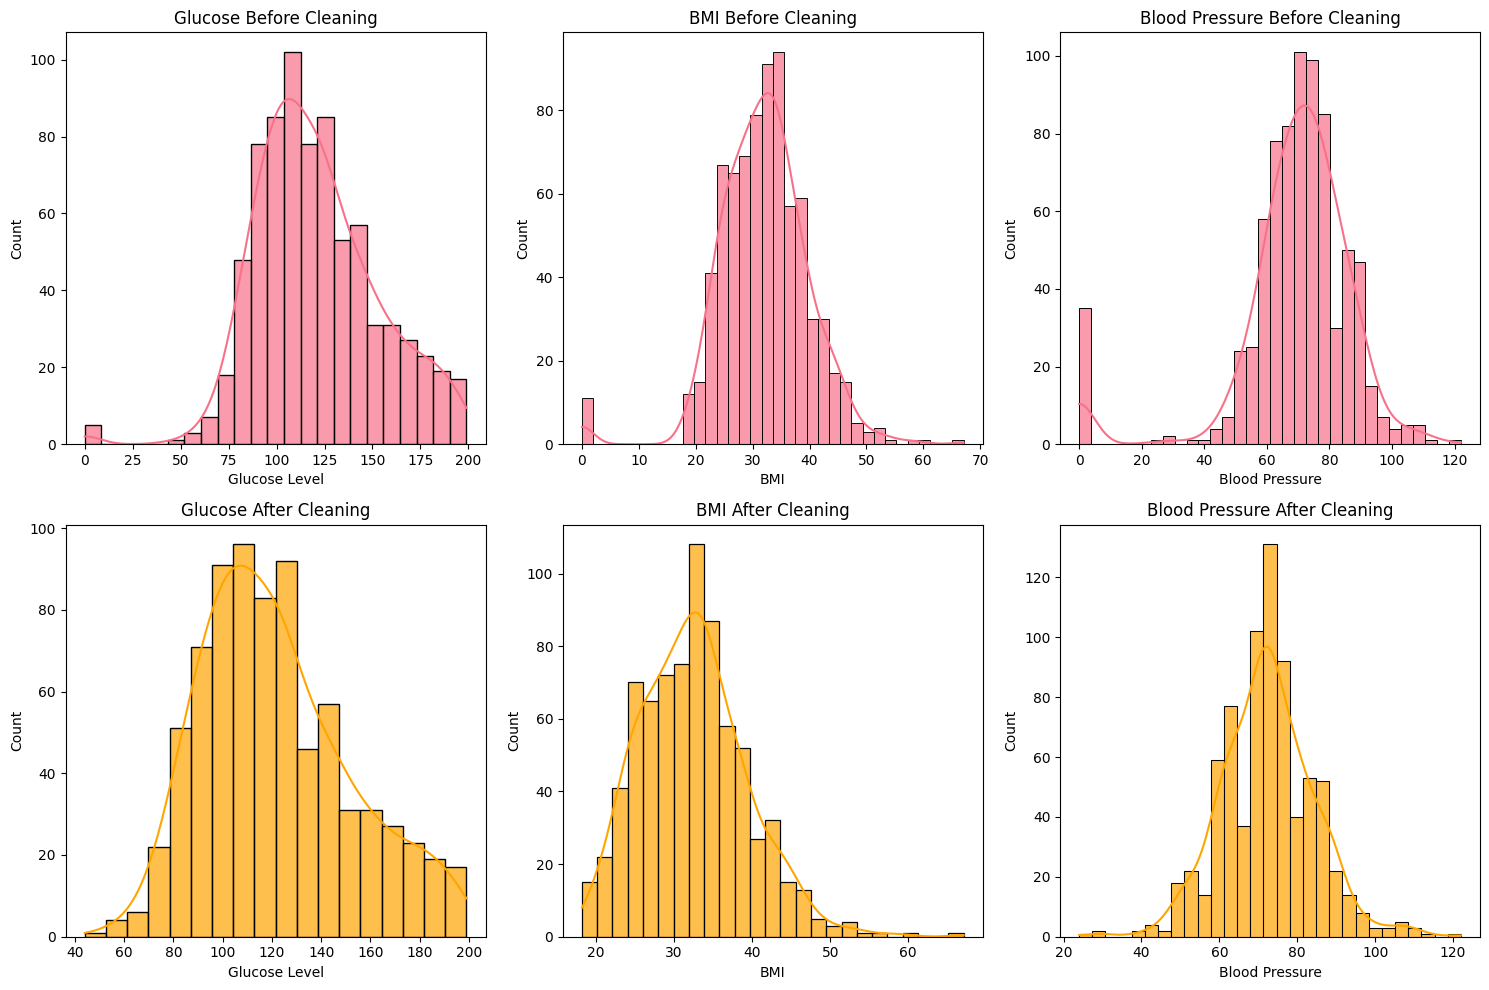

Saved visualization as 'distributions_comparison.png'
Note: Distributions look less skewed now, no big zero spikes!


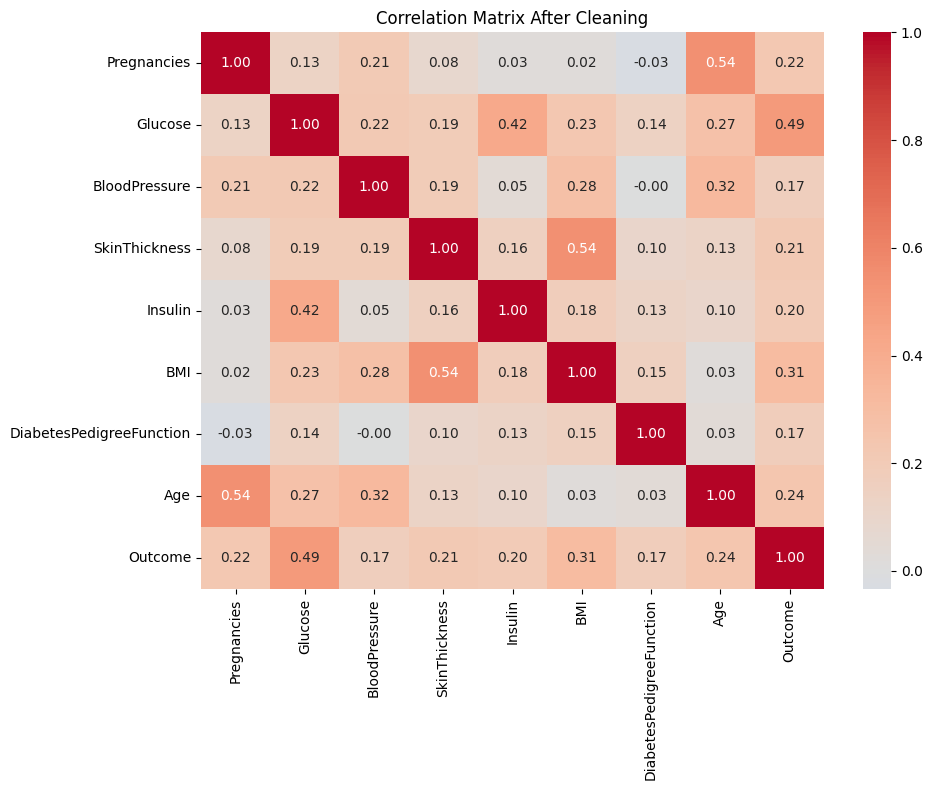

In [ ]:
# Before cleaning - histograms
plt.figure(figsize=(15, 10))

# Glucose comparison
plt.subplot(2, 3, 1)
sns.histplot(df_raw['Glucose'], kde=True, alpha=0.7)
plt.title('Glucose Before Cleaning')
plt.xlabel('Glucose Level')

plt.subplot(2, 3, 4)
sns.histplot(df['Glucose'], kde=True, alpha=0.7, color='orange')
plt.title('Glucose After Cleaning')
plt.xlabel('Glucose Level')

# BMI comparison
plt.subplot(2, 3, 2)
sns.histplot(df_raw['BMI'], kde=True, alpha=0.7)
plt.title('BMI Before Cleaning')
plt.xlabel('BMI')

plt.subplot(2, 3, 5)
sns.histplot(df['BMI'], kde=True, alpha=0.7, color='orange')
plt.title('BMI After Cleaning')
plt.xlabel('BMI')

# BloodPressure comparison
plt.subplot(2, 3, 3)
sns.histplot(df_raw['BloodPressure'], kde=True, alpha=0.7)
plt.title('Blood Pressure Before Cleaning')
plt.xlabel('Blood Pressure')

plt.subplot(2, 3, 6)
sns.histplot(df['BloodPressure'], kde=True, alpha=0.7, color='orange')
plt.title('Blood Pressure After Cleaning')
plt.xlabel('Blood Pressure')

plt.tight_layout()
plt.savefig('distributions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n\n')
print("Saved visualization as 'distributions_comparison.png'")
print("Note: Distributions look less skewed now, no big zero spikes!")
print('\n')
# Correlation heatmap for cleaned data
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix After Cleaning')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Model Training and Comparison

In [ ]:
# On raw data - Logistic Regression
model_raw_lr = LogisticRegression(max_iter=1000, random_state=42)
model_raw_lr.fit(X_train_raw, y_train_raw)
y_pred_raw_lr = model_raw_lr.predict(X_test_raw)
raw_accuracy_lr = accuracy_score(y_test_raw, y_pred_raw_lr)

print(f'RAW Data - Logistic Regression Accuracy: {raw_accuracy_lr:.4f}')
print('RAW Data - Logistic Regression Classification Report:')
print(classification_report(y_test_raw, y_pred_raw_lr))

# On raw data - Random Forest
model_raw_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_raw_rf.fit(X_train_raw, y_train_raw)
y_pred_raw_rf = model_raw_rf.predict(X_test_raw)
raw_accuracy_rf = accuracy_score(y_test_raw, y_pred_raw_rf)

print(f'RAW Data - Random Forest Accuracy: {raw_accuracy_rf:.4f}')

print("\nTraining models on PREPROCESSED data...")

# On preprocessed data - Logistic Regression
model_clean_lr = LogisticRegression(max_iter=1000, random_state=42)
model_clean_lr.fit(X_train_scaled, y_train)
y_pred_clean_lr = model_clean_lr.predict(X_test_scaled)
clean_accuracy_lr = accuracy_score(y_test, y_pred_clean_lr)

print(f'CLEAN Data - Logistic Regression Accuracy: {clean_accuracy_lr:.4f}')
print('CLEAN Data - Logistic Regression Classification Report:')
print(classification_report(y_test, y_pred_clean_lr))

# On preprocessed data - Random Forest (on non-scaled for fair comparison)
model_clean_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_clean_rf.fit(X_train, y_train)  # RF doesn't need scaling
y_pred_clean_rf = model_clean_rf.predict(X_test)
clean_accuracy_rf = accuracy_score(y_test, y_pred_clean_rf)

print(f'CLEAN Data - Random Forest Accuracy: {clean_accuracy_rf:.4f}')

RAW Data - Logistic Regression Accuracy: 0.7468
RAW Data - Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

RAW Data - Random Forest Accuracy: 0.7208

Training models on PREPROCESSED data...
CLEAN Data - Logistic Regression Accuracy: 0.7532
CLEAN Data - Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

CLEAN Data - Random Forest Accuracy: 0.7468


## 7. Performance Comparison

MODEL PERFORMANCE COMPARISON:
Model                Raw Data     Clean Data   Improvement 
------------------------------------------------------------
Logistic Regression  0.7468       0.7532       0.0065      
Random Forest        0.7208       0.7468       0.0260      

Key Insights:
- Preprocessing improved Logistic Regression by 0.0065 (0.65%)
- Preprocessing improved Random Forest by 0.0260 (2.60%)
- Total problematic zeros handled: 652


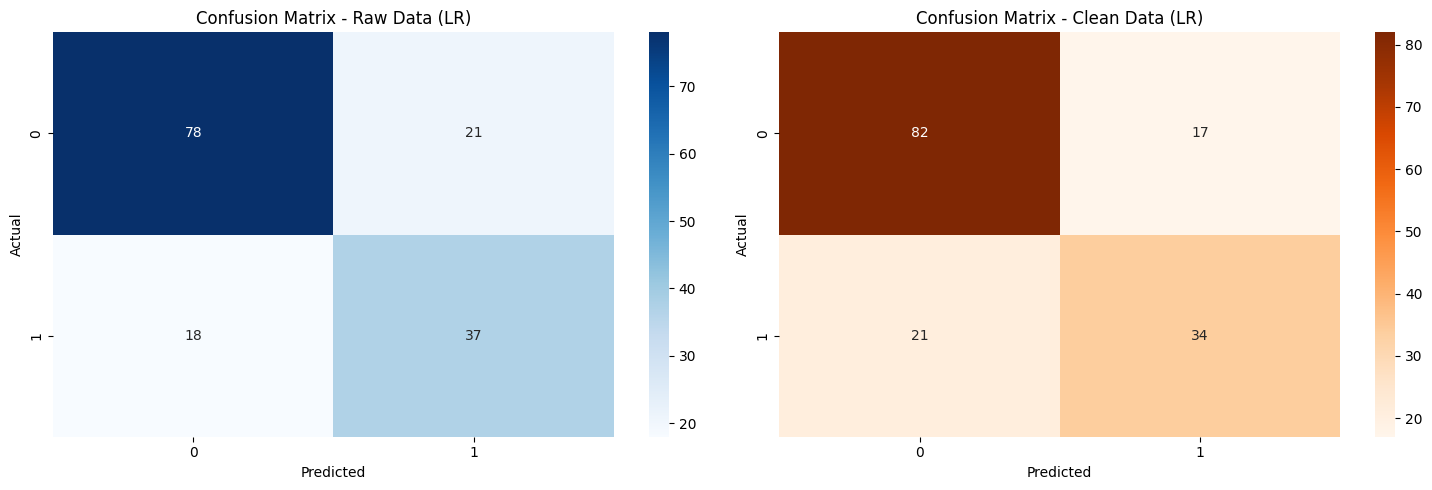

Saved confusion matrices as 'confusion_matrices.png'


In [ ]:
# Comparison summary
improvements = {
    'Logistic Regression': clean_accuracy_lr - raw_accuracy_lr,
    'Random Forest': clean_accuracy_rf - raw_accuracy_rf
}

print("MODEL PERFORMANCE COMPARISON:")
print(f"{'Model':<20} {'Raw Data':<12} {'Clean Data':<12} {'Improvement':<12}")
print("-" * 60)
print(f"{'Logistic Regression':<20} {raw_accuracy_lr:<12.4f} {clean_accuracy_lr:<12.4f} {improvements['Logistic Regression']:<12.4f}")
print(f"{'Random Forest':<20} {raw_accuracy_rf:<12.4f} {clean_accuracy_rf:<12.4f} {improvements['Random Forest']:<12.4f}")

print(f"\nKey Insights:")
print(f"- Preprocessing improved Logistic Regression by {improvements['Logistic Regression']:.4f} ({improvements['Logistic Regression']*100:.2f}%)")
print(f"- Preprocessing improved Random Forest by {improvements['Random Forest']:.4f} ({improvements['Random Forest']*100:.2f}%)")
print(f"- Total problematic zeros handled: {total_zeros}")

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw data confusion matrix
cm_raw = confusion_matrix(y_test_raw, y_pred_raw_lr)
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Raw Data (LR)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Clean data confusion matrix
cm_clean = confusion_matrix(y_test, y_pred_clean_lr)
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Confusion Matrix - Clean Data (LR)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved confusion matrices as 'confusion_matrices.png'")

## Reflections on lifecycle

In [ ]:
print("""
Lifecycle question: What would go wrong if preprocessing is skipped?

If we skip preprocessing, several issues arise in the ML lifecycle:

1. Training phase: The model learns from incorrect data
   (considering zeros as real values)
   - Glucose=0 gets treated as a valid measurement when it's actually missing
   - This creates false patterns and biased decision boundaries
   - This could lead to incorrect predictions in production and establish wrong
     practices

2. Prediction phase: When deployed, the model makes wrong predictions
   - A patient with actual zero recorded for missing glucose might get
     incorrect diabetes probability
   - This could lead to misdiagnosis in real healthcare scenarios
   - This could be lifethreatning in real-world scenarios

3. Monitoring phase: Model performance degrades over time because
   - The underlying data quality issues propagate through the system
   - Drift detection becomes harder when baseline contains errors

4. Maintenance phase: More complex debugging and fixes needed
   - Harder to trace prediction errors back to data quality. This could lead to
     loss of resources and time
   - Requires retraining with proper preprocessing

Personal coding experience:

In an assignment of ML in last trimester which needed performing
linear regression on a dataset to predict a person's weight from their height,
I encountered a similar issue. My program failed with a KeyError when i tried
to access the 'Height' column. After some debugging i found that the column in
raw data file was actually named 'Height ' with a trailing whitespace character.

This was not a machine learning problem but a data integrity issue. I resolved
it using a standard programming function,
df.columns = df.columns.str.strip(),
to clean column names. This simple fix prevented program from crashing and
allowed analysis to run correctly.

This is similar to problem in Pima Diabetes dataset. Just as a trailing space is
an invalid part of a column name, a value of 0 for 'Glucose' or 'BMI' is an
invalid diagnostic value. A standard defensive programming approach to double
check with validation after loading data, could avoid this.

My simple validation check was:
# A simple check to flag biologically impossible values
if (df['Glucose'] == 0).any():
    print("Warning: Glucose column contains zero values,
    which may indicate missing data.")

This type of sanity checks doesnt require specialised ML liabraries. Its a
fundamental programming practice to validate inputs before processing them.
Hence i think data quality problems can and should be caught early using normal
programming techniques.

However this doesnt mean that normal programming techniques could be an
alternative for ML techiniques. What normal software development cant catch is:
- If data really makes sense in practical scenarios
- What method to use for preprocessing that can adapt to our data and
  requirements
- Domain specific knowledge of lets say finance, health or
  legal documents proccessing

This is where ML programming and techniques differ from normal software
development. In normal software programming we make the rules and provide input.
In ML algorithm or a model comes up with rules according to our data.

""")


Lifecycle question: What would go wrong if preprocessing is skipped?

If we skip preprocessing, several issues arise in the ML lifecycle:

1. Training phase: The model learns from incorrect data 
   (considering zeros as real values)
   - Glucose=0 gets treated as a valid measurement when it's actually missing
   - This creates false patterns and biased decision boundaries
   - This could lead to incorrect predictions in production and establish wrong 
     practices

2. Prediction phase: When deployed, the model makes wrong predictions
   - A patient with actual zero recorded for missing glucose might get 
     incorrect diabetes probability
   - This could lead to misdiagnosis in real healthcare scenarios
   - This could be lifethreatning in real-world scenarios

3. Monitoring phase: Model performance degrades over time because
   - The underlying data quality issues propagate through the system
   - Drift detection becomes harder when baseline contains errors

4. Maintenance phase: